<a href="https://colab.research.google.com/github/shreyankaul/scaler/blob/main/yulu_sk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
from scipy.stats import kruskal
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

In [ ]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv?1642089089 -O yulu_data.csv

--2026-05-20 14:17:22--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv?1642089089
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 3.169.117.127, 3.169.117.63, 3.169.117.172, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|3.169.117.127|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 648353 (633K) [text/plain]
Saving to: ‘yulu_data.csv’

yulu_data.csv       100%[===================>] 633.16K  --.-KB/s    in 0.07s   

2026-05-20 14:17:22 (8.53 MB/s) - ‘yulu_data.csv’ saved [648353/648353]



In [ ]:
df = pd.read_csv('/content/yulu_data.csv')

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [ ]:
df.shape

(10886, 12)

In [ ]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [ ]:
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour

In [ ]:
cat_cols = ['season', 'holiday', 'workingday', 'weather']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  hour        10886 non-null  int32         
dtypes: category(4), datetime64[ns](1), float64(3), int32(3), int64(4)
memo

In [ ]:
df['season'] = df['season'].replace({
    1:'Spring',
    2:'Summer',
    3:'Fall',
    4:'Winter'
})

df['holiday'] = df['holiday'].replace({
    0:'No',
    1:'Yes'
})

df['workingday'] = df['workingday'].replace({
    0:'No',
    1:'Yes'
})

df['weather'] = df['weather'].replace({
    1:'Clear',
    2:'Mist + Cloudy',
    3:'Light Rain/Snow',
    4:'Heavy Rain'
})

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,hour
0,2011-01-01 00:00:00,Spring,No,No,Clear,9.84,14.395,81,0.0,3,13,16,2011,1,0
1,2011-01-01 01:00:00,Spring,No,No,Clear,9.02,13.635,80,0.0,8,32,40,2011,1,1
2,2011-01-01 02:00:00,Spring,No,No,Clear,9.02,13.635,80,0.0,5,27,32,2011,1,2
3,2011-01-01 03:00:00,Spring,No,No,Clear,9.84,14.395,75,0.0,3,10,13,2011,1,3
4,2011-01-01 04:00:00,Spring,No,No,Clear,9.84,14.395,75,0.0,0,1,1,2011,1,4


#Univariate Analysis
Continuous Variables Analysis

Histogram

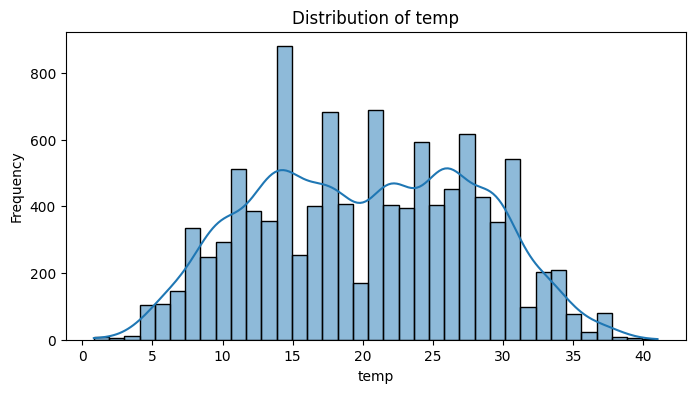

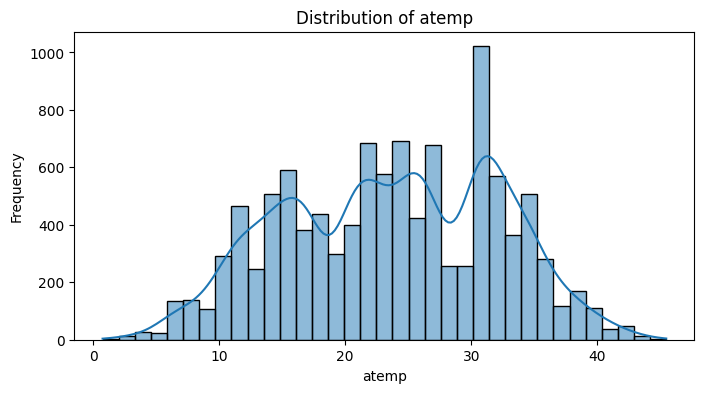

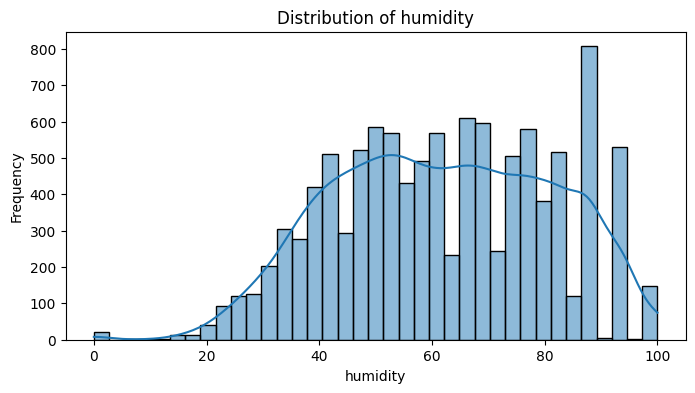

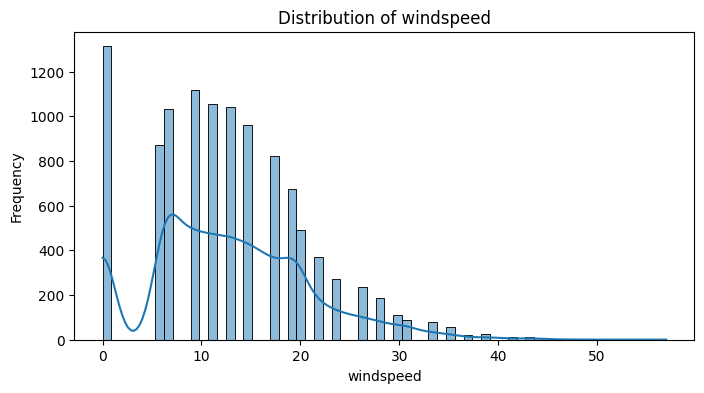

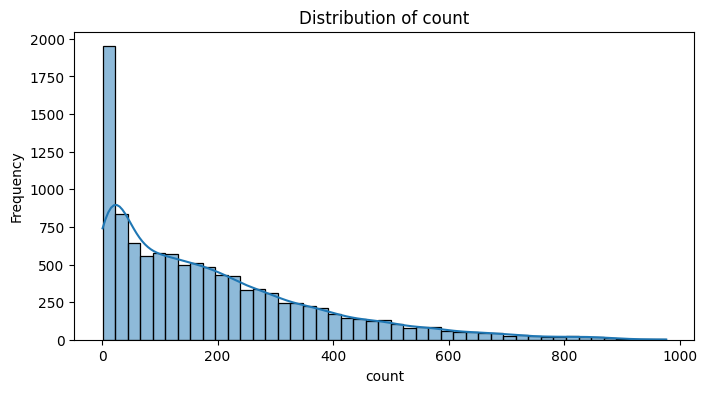

In [ ]:
cont_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'count']

for col in cont_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], kde=True)

    plt.title(f'Distribution of {col}')

    plt.xlabel(col)

    plt.ylabel('Frequency')

    plt.show()

**Observations from Histogram Analysis**

- The variables 'temp' and 'atemp' show approximately bell-shaped distributions, indicating relatively balanced temperature observations across the dataset.

- 'humidity' values are concentrated mostly between moderate to high levels, suggesting that bike rental activity frequently occurs under humid conditions.

- 'windspeed' is positively skewed, with most observations concentrated at lower windspeed values and relatively fewer observations at extremely high wind speeds.

- The target variable 'count' is heavily right-skewed, indicating that most time periods experience moderate bike rental demand while a small number of observations show extremely high rental counts.

- The skewness observed in 'count' suggests that the data may not follow a normal distribution, which becomes important while selecting appropriate statistical tests later in the analysis.

Boxplot

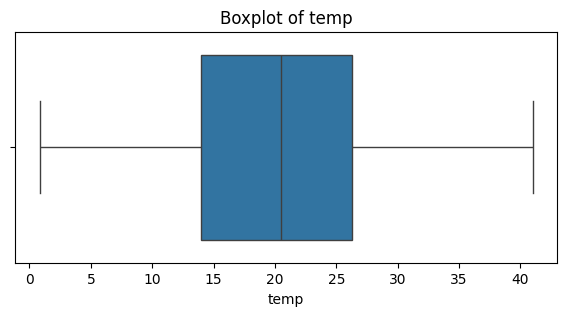

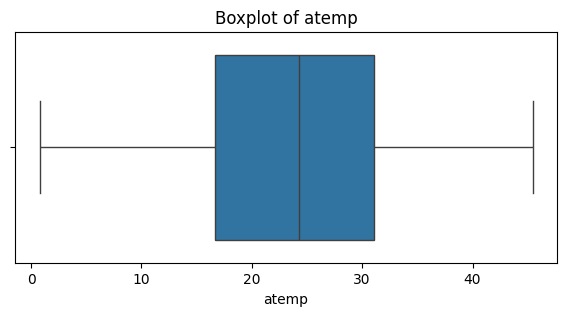

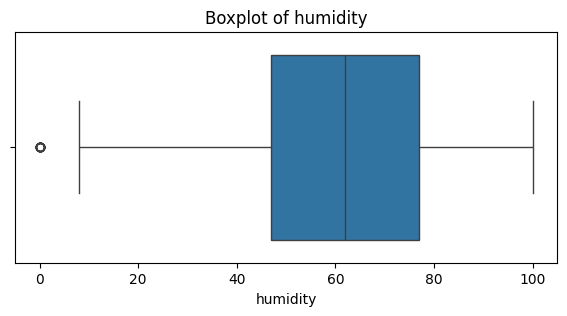

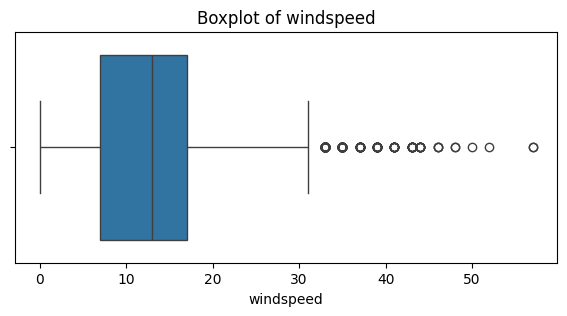

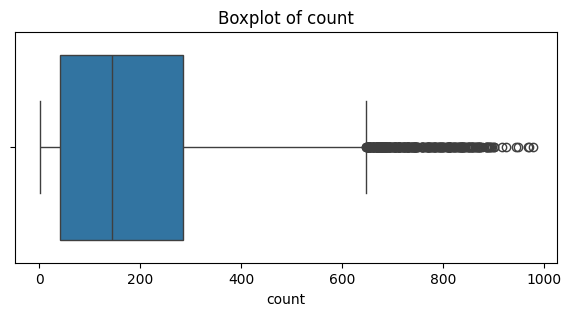

In [ ]:
for col in cont_cols:

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

**Observations from Boxplot Analysis**

- The variables 'temp' and 'atemp' do not show significant outliers and appear relatively symmetrically distributed.

- 'humidity' shows a few minor lower-end outliers, but overall the distribution remains fairly stable.

- 'windspeed' contains multiple upper-end outliers, indicating that extremely high windspeed conditions occur infrequently.

- The target variable 'count' contains a large number of upper-end outliers and exhibits substantial variability in bike rental demand.

- The presence of extreme values and skewness in 'count' further suggests that the variable may not follow a normal distribution.

- High rental outliers may correspond to peak commuting hours, favorable weather conditions, or seasonal demand surges.

Categorical Variable Analysis

Countplots

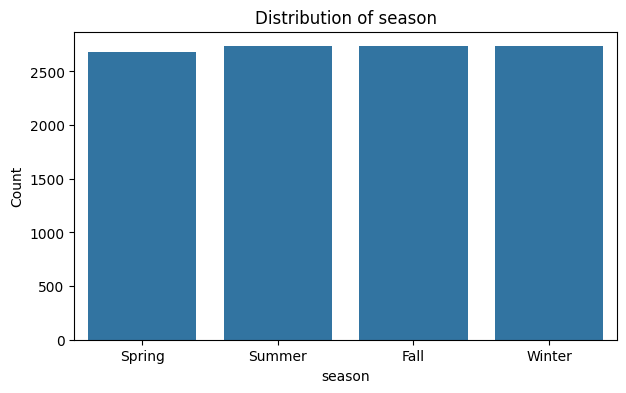

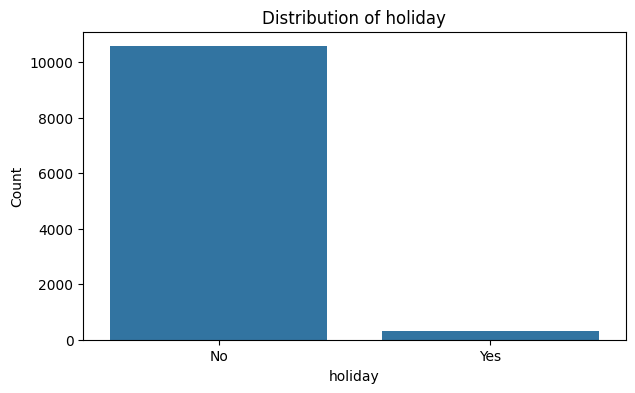

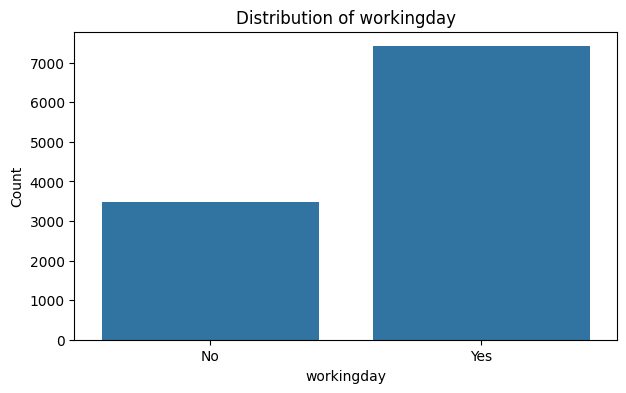

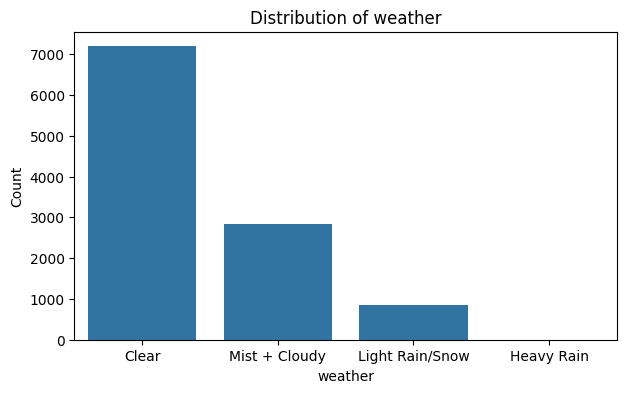

In [ ]:
cat_cols = ['season', 'holiday', 'workingday', 'weather']

for col in cat_cols:

    plt.figure(figsize=(7,4))

    sns.countplot(x=col, data=df)

    plt.title(f'Distribution of {col}')

    plt.xlabel(col)

    plt.ylabel('Count')

    plt.show()

**Observations from Categorical Variable Analysis**

- The dataset is fairly balanced across all four seasons, allowing reliable seasonal comparisons.

- Non-holiday observations are significantly higher than holiday observations, indicating that most rental activity was recorded during regular days.

- Working days occur more frequently than non-working days in the dataset.

- Most observations belong to clear weather conditions, while severe weather conditions occur very rarely.

- The low frequency of extreme weather conditions may influence statistical testing and demand analysis across weather categories.

#Bivariate Analysis

Working Day vs Count

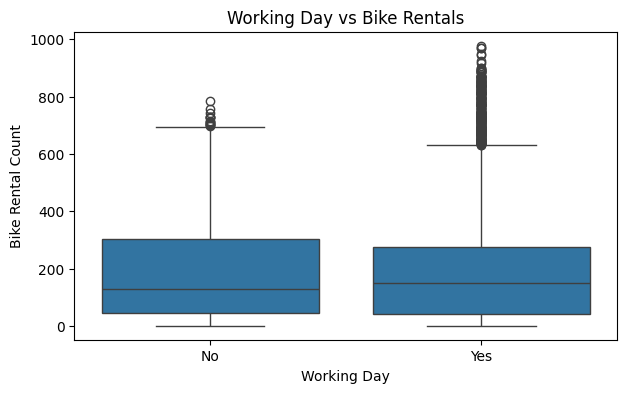

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(x='workingday', y='count', data=df)

plt.title('Working Day vs Bike Rentals')

plt.xlabel('Working Day')

plt.ylabel('Bike Rental Count')

plt.show()

Observation

Bike rental demand appears slightly higher during working days compared to non-working days, indicating that commuting demand may contribute significantly to Yulu’s rentals.

Season vs Count

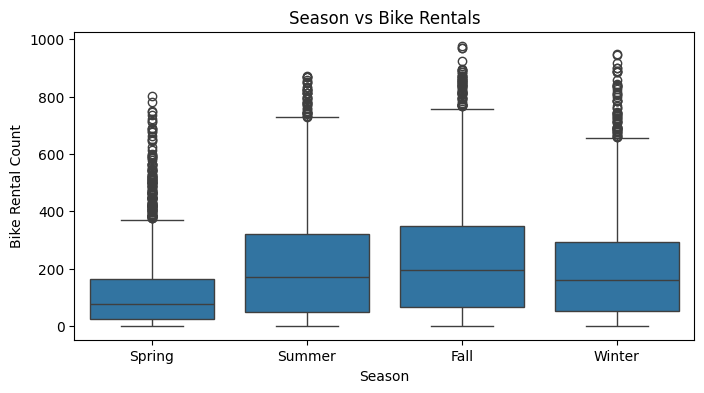

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x='season', y='count', data=df)

plt.title('Season vs Bike Rentals')

plt.xlabel('Season')

plt.ylabel('Bike Rental Count')

plt.show()

Observation

Bike rental demand varies across seasons. Higher median rentals are observed during Fall and Summer seasons, suggesting that favorable climatic conditions positively influence bike usage.

Weather vs Count

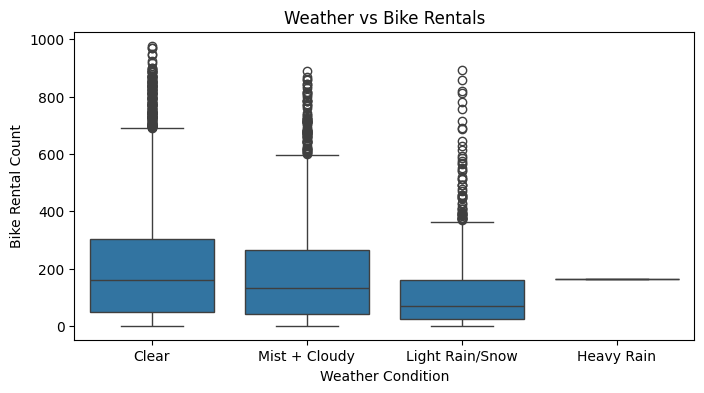

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x='weather', y='count', data=df)

plt.title('Weather vs Bike Rentals')

plt.xlabel('Weather Condition')

plt.ylabel('Bike Rental Count')

plt.show()

Observation

Bike rental demand decreases significantly under unfavorable weather conditions. Clear weather conditions show the highest rental demand, while rainy or snowy conditions show comparatively lower rentals.

#Correlation Analysis
Correlation Heatmap

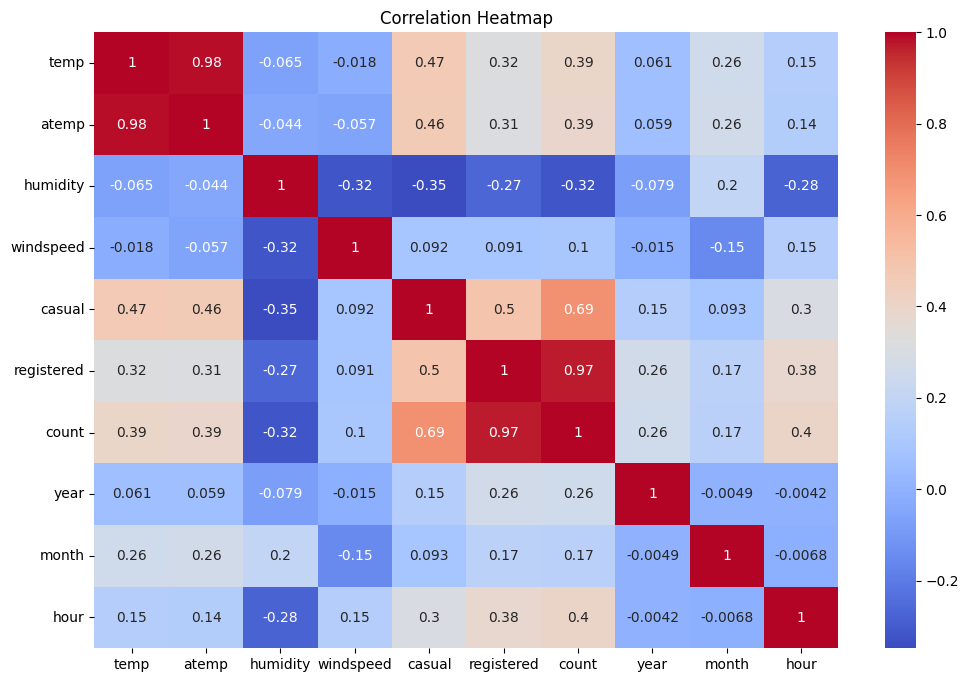

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**Observations from Correlation Analysis**

- 'temp' and 'atemp' show extremely high positive correlation, indicating strong multicollinearity between the two variables.

- 'count' is highly positively correlated with both 'registered' and 'casual' users since total rentals are derived from these two variables.

- Humidity shows a moderate negative correlation with bike rentals, suggesting that higher humidity may reduce demand.

- Temperature variables show a positive relationship with bike rental demand, indicating that favorable temperatures encourage bike usage.

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,Year,Month,Hour,year,month,hour
0,2011-01-01 00:00:00,Spring,No,No,Clear,9.84,14.395,81,0.0,3,13,16,2011,1,0,2011,1,0
1,2011-01-01 01:00:00,Spring,No,No,Clear,9.02,13.635,80,0.0,8,32,40,2011,1,1,2011,1,1
2,2011-01-01 02:00:00,Spring,No,No,Clear,9.02,13.635,80,0.0,5,27,32,2011,1,2,2011,1,2
3,2011-01-01 03:00:00,Spring,No,No,Clear,9.84,14.395,75,0.0,3,10,13,2011,1,3,2011,1,3
4,2011-01-01 04:00:00,Spring,No,No,Clear,9.84,14.395,75,0.0,0,1,1,2011,1,4,2011,1,4
